# Тест 3 — влияние взвешивания лосса


In [ ]:

import os, sys
assert os.path.exists('pinn_core.py'),                'нужен pinn_core.py в корне сессии'
assert os.path.exists('cell_viz_v4.py'),              'нужен cell_viz_v4.py'
assert os.path.exists('test3_weighting_common.py'),   'нужен test3_weighting_common.py'

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from pathlib import Path


%run -i pinn_core.py
%run -i cell_viz_v4.py
%run -i test3_weighting_common.py

print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)

RESULTS_DIR = Path('results'); RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR   = Path('plots');   PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_PATH = RESULTS_DIR / 'test3_weighting.pkl'

PINN Solver loaded
test3_weighting_common.py loaded
Device: cuda
Torch: 2.6.0+cu124


## Конфигурация эксперимента

In [ ]:
TASKS = all_tasks()

CONFIGS = make_weighting_configs()


TRAIN_KWARGS = dict(
    n_epochs_adam=6000,
    lbfgs_max_iter=1500,
    use_lbfgs=True,
    early_stop_patience=300,
    early_stop_rtol=1e-9,
    lr=1e-3,
    sampling='random',
    scheduler_type='cosine',
)

print(f'{len(CONFIGS)} конфигов × {len(TASKS)} задач = {len(CONFIGS) * len(TASKS)} прогонов')
print('\nЗадачи:')
for t in TASKS:
    arch = t['default_arch']
    pts = t['default_points']
    print(f"  {t['short']:10s}  {arch['hidden_size']}×{arch['num_hidden_layers']}, "
          f"act={arch['activation']}, n_coll={pts['n_collocation']}, "
          f"n_cond={pts['n_condition']}, ndim={len(t['domain'])}")

print('\nКонфиги взвешивания:')
for c in CONFIGS:
    print(f"  {c['config_id']:15s}  {c['label']:25s}  ({c['group']})")

7 конфигов × 4 задач = 28 прогонов

Задачи:
  ЛР2 №2      96×5, act=tanh, n_coll=3000, n_cond=300, ndim=2
  ЛР2 №4      96×5, act=tanh, n_coll=3000, n_cond=300, ndim=2
  ЛР3 №5      80×5, act=tanh, n_coll=2500, n_cond=300, ndim=2
  ЛР4 №10     128×5, act=tanh, n_coll=5000, n_cond=500, ndim=3

Конфиги взвешивания:
  fixed_lc1        fixed λ_c=1                (fixed)
  fixed_lc5        fixed λ_c=5                (fixed)
  fixed_lc10       fixed λ_c=10               (fixed)
  fixed_lc50       fixed λ_c=50               (fixed)
  fixed_lc100      fixed λ_c=100              (fixed)
  softadapt        softadapt                  (adaptive)
  grad_norm        grad_norm                  (adaptive)


## Главный эксперимент

In [4]:
results = run_grid(
    tasks=TASKS,
    configs=CONFIGS,
    train_kwargs=TRAIN_KWARGS,
    save_path=RESULTS_PATH,
    seed=42,
    verbose=True,
)
print(f'\n{len(results)} результатов сохранено в {RESULTS_PATH}')

[ 1/28] lr2_v2     / fixed_lc1      
   rel_l2=5.379e-02  max|Δ|=3.335e-01  time=178.6s  λr=1  λc=1
[ 2/28] lr2_v2     / fixed_lc5        ETA ~77 мин
   rel_l2=7.738e-02  max|Δ|=4.841e-01  time=172.4s  λr=1  λc=5
[ 3/28] lr2_v2     / fixed_lc10       ETA ~73 мин
   rel_l2=9.185e-02  max|Δ|=5.798e-01  time=169.9s  λr=1  λc=10
[ 4/28] lr2_v2     / fixed_lc50       ETA ~69 мин
   rel_l2=9.866e-02  max|Δ|=6.261e-01  time=169.0s  λr=1  λc=50
[ 5/28] lr2_v2     / fixed_lc100      ETA ~66 мин
   rel_l2=9.203e-02  max|Δ|=5.989e-01  time=169.0s  λr=1  λc=1e+02
[ 6/28] lr2_v2     / softadapt        ETA ~63 мин
   rel_l2=5.858e-02  max|Δ|=3.651e-01  time=170.3s  λr=1  λc=1
[ 7/28] lr2_v2     / grad_norm        ETA ~60 мин
   rel_l2=1.201e-01  max|Δ|=7.461e-01  time=243.3s  λr=16  λc=0.52
[ 8/28] lr2_v4     / fixed_lc1        ETA ~61 мин
   rel_l2=5.266e-02  max|Δ|=5.294e-01  time=163.3s  λr=1  λc=1
[ 9/28] lr2_v4     / fixed_lc5        ETA ~57 мин
   rel_l2=7.907e-02  max|Δ|=7.569e-01  time=164.0

## Сводка результатов

In [ ]:

results = load_results(RESULTS_PATH)
print(f'Загружено {len(results)} результатов')

Загружено 28 результатов


In [ ]:

df = results_to_dataframe(results)
print('Размер DataFrame:', df.shape)
df.head(10)

Размер DataFrame: (28, 16)


,task,config_id,method,group,lambda_cond_init,rel_l2,abs_max,final_total,final_residual,final_conditions,final_lambda_res,final_lambda_cond,time_s,n_params,failed,err_msg
0,lr2_v2,fixed_lc1,fixed,fixed,1.0,0.053794,0.333465,0.000062,0.000029,0.000032,1.000000,1.000000,178.622882,37633,False,
1,lr2_v2,fixed_lc5,fixed,fixed,5.0,0.077379,0.484061,0.000229,0.000160,0.000014,1.000000,5.000000,172.380884,37633,False,
2,lr2_v2,fixed_lc10,fixed,fixed,10.0,0.091847,0.579827,0.000403,0.000339,0.000006,1.000000,10.000000,169.886498,37633,False,
3,lr2_v2,fixed_lc50,fixed,fixed,50.0,0.098661,0.626114,0.000779,0.000612,0.000003,1.000000,50.000000,169.005661,37633,False,
4,lr2_v2,fixed_lc100,fixed,fixed,100.0,0.092031,0.598926,0.001219,0.000904,0.000003,1.000000,100.000000,169.010380,37633,False,
5,lr2_v2,softadapt,softadapt,adaptive,10.0,0.058577,0.365117,0.000068,0.000033,0.000035,1.000000,1.000000,170.265476,37633,False,
6,lr2_v2,grad_norm,grad_norm,adaptive,10.0,0.120092,0.746132,0.000632,0.000003,0.001130,15.797923,0.516601,243.259997,37633,False,
7,lr2_v4,fixed_lc1,fixed,fixed,1.0,0.052658,0.529449,0.005615,0.003280,0.002335,1.000000,1.000000,163.280514,37633,False,
8,lr2_v4,fixed_lc5,fixed,fixed,5.0,0.079066,0.756873,0.020989,0.014589,0.001280,1.000000,5.000000,163.950945,37633,False,
9,lr2_v4,fixed_lc10,fixed,fixed,10.0,0.116148,1.150955,0.046586,0.030247,0.001634,1.000000,10.000000,163.003103,37633,False,


In [ ]:

print_summary_table(results, TASKS)

СВОДКА: 28 прогонов

>>> ЛР2 №2   (7 OK, 0 FAILED)
  config_id    method rel_l2 abs_max final_lambda_cond time_s
  fixed_lc1     fixed   0.05    0.33              1.00 178.62
  softadapt softadapt   0.06    0.37              1.00 170.27
  fixed_lc5     fixed   0.08    0.48              5.00 172.38
 fixed_lc10     fixed   0.09    0.58             10.00 169.89
fixed_lc100     fixed   0.09    0.60            100.00 169.01
 fixed_lc50     fixed   0.10    0.63             50.00 169.01
  grad_norm grad_norm   0.12    0.75              0.52 243.26

>>> ЛР2 №4   (7 OK, 0 FAILED)
  config_id    method rel_l2 abs_max final_lambda_cond time_s
  fixed_lc1     fixed   0.05    0.53              1.00 163.28
  fixed_lc5     fixed   0.08    0.76              5.00 163.95
 fixed_lc10     fixed   0.12    1.15             10.00 163.00
  softadapt softadapt   0.16    1.61              1.00 169.68
  grad_norm grad_norm   0.25    2.49             15.90 259.80
 fixed_lc50     fixed   0.48    5.11             5

## Главный график: Rel L2 vs метод взвешивания


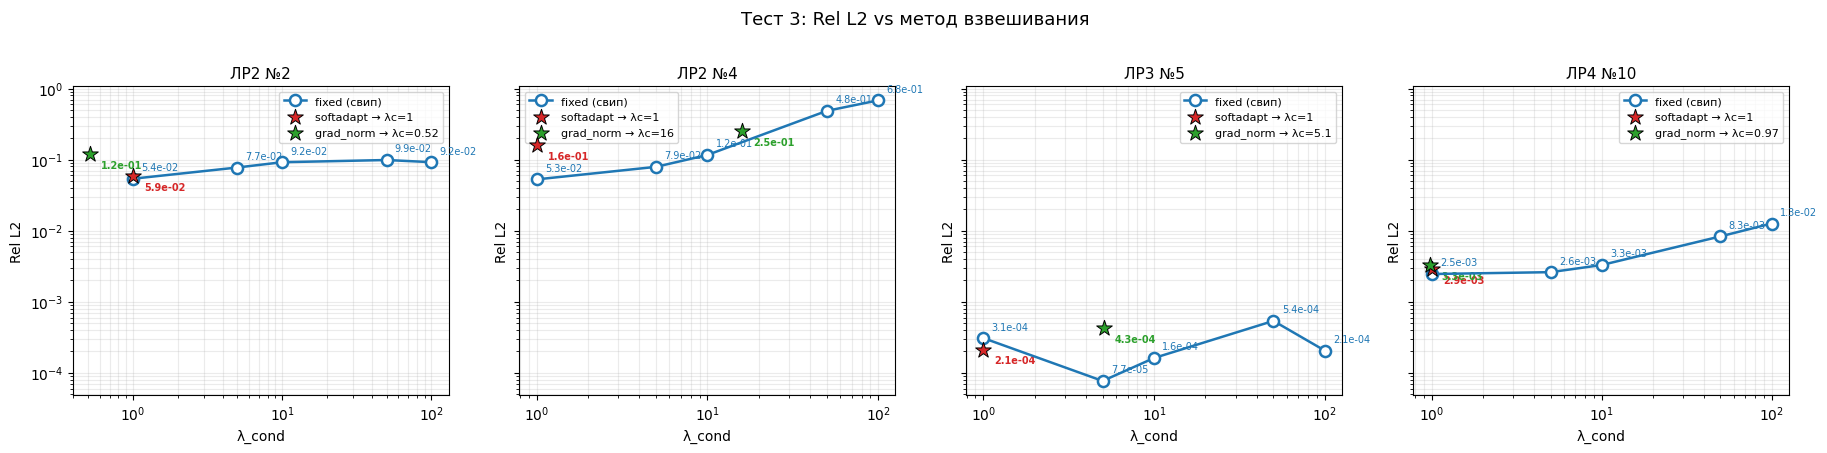

In [8]:
plot_lambda_sweep_4tasks(
    results, TASKS,
    save_path=PLOTS_DIR / 'test3_lambda_sweep.png',
)

## Все методы рядом для каждой задачи

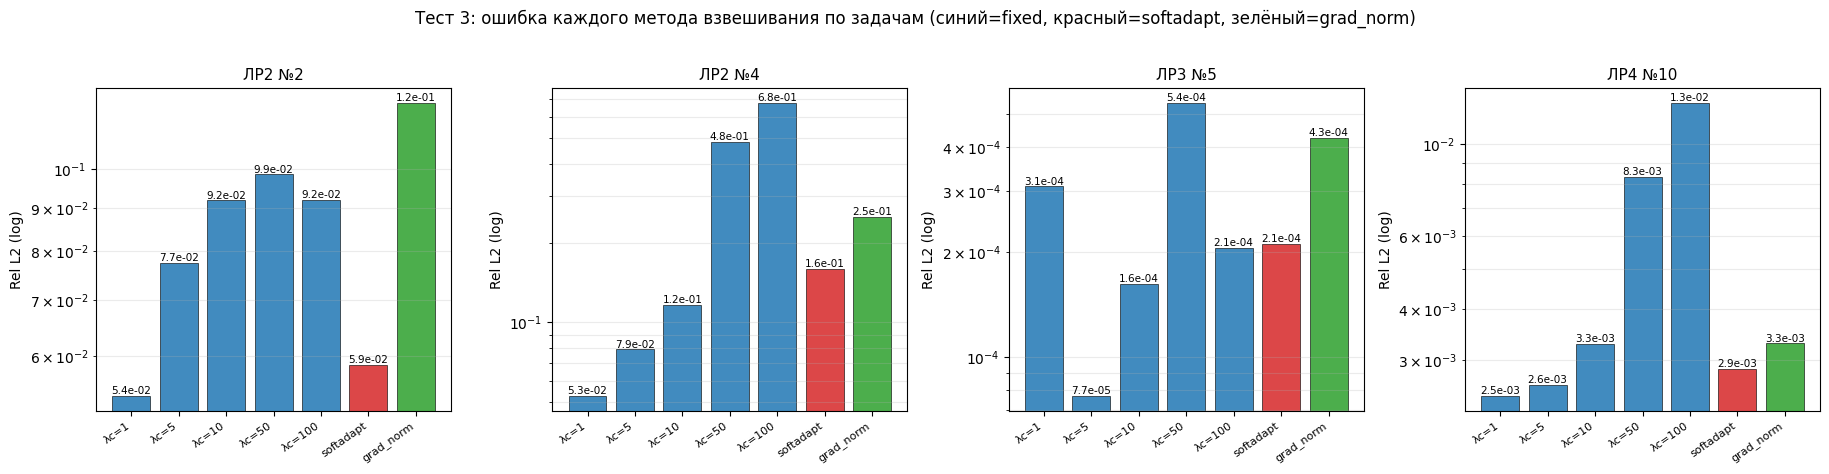

In [9]:
plot_methods_barchart(
    results, TASKS,
    save_path=PLOTS_DIR / 'test3_methods_barchart.png',
)

## Эволюция `λ_res`, `λ_cond` во времени

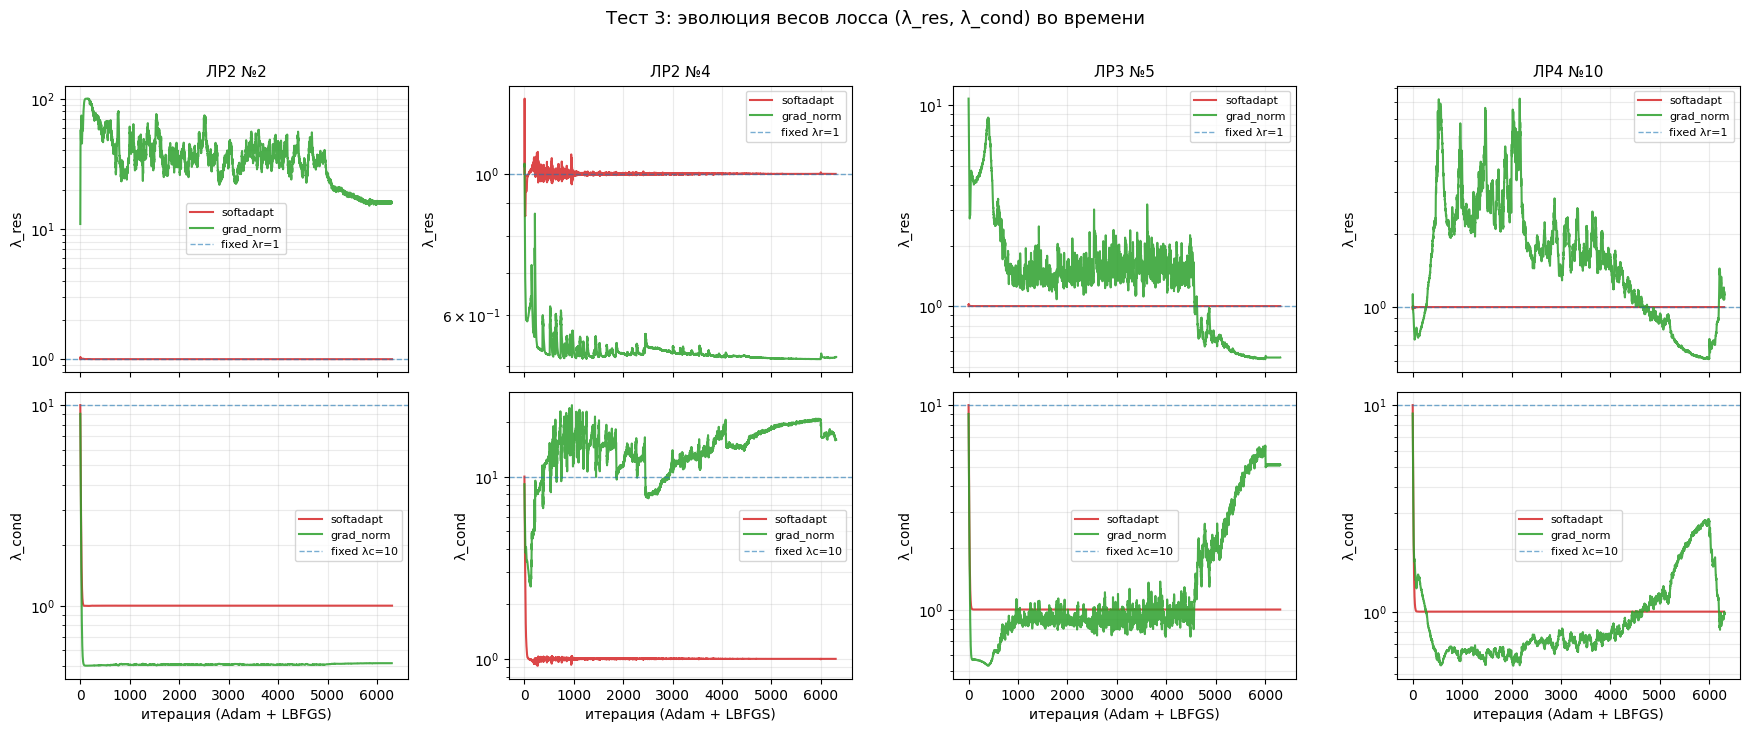

In [10]:
plot_lambda_evolution(
    results, TASKS,
    save_path=PLOTS_DIR / 'test3_lambda_evolution.png',
)

## Кривые training loss

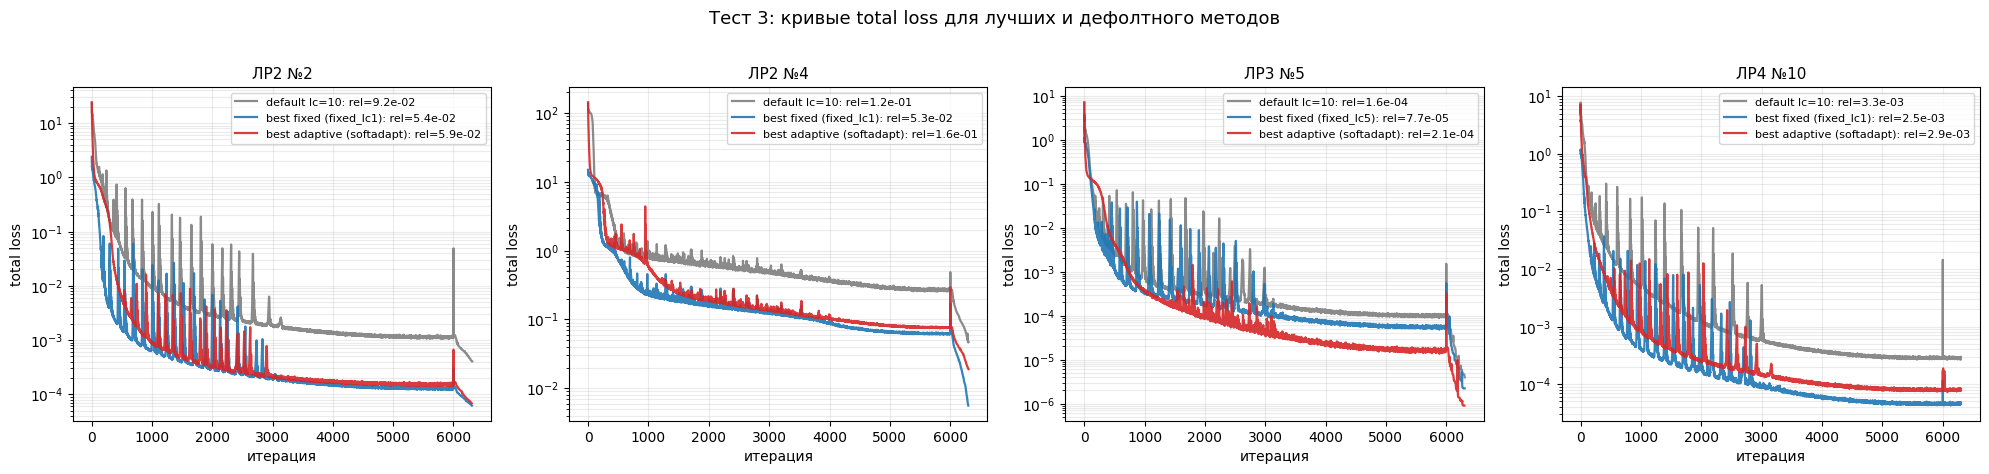

In [11]:
plot_loss_components_per_task(
    results, TASKS,
    save_path=PLOTS_DIR / 'test3_loss_curves.png',
)